## Taxa de Alfabetização vs Acesso ao Saneamento Básico e Água no Ano de 2022:
### Uma Análise do Censo 2022 e do Sistema Nacional de Informações sobre Saneamento (SNIS)

Discentes: Guilherme da Silva Ferraz, Vinicius Mariano de Campos.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Parte 1 – Preparação dos dados

## 1. Compreensão Inicial dos Dados

### Carregar o Dataset e Visualizar os Dados

In [ ]:
dadoCenso = pd.read_csv('br_ibge_censo_2022_alfabetizacao_grupo_idade_sexo_raca.csv', encoding='UTF-8', sep=',')
dadoSNIS = pd.read_csv('br_mdr_snis_municipio_agua_esgoto.csv', encoding='UTF-8', sep=',')

### Filtrando os Dados e Selecionando Apenas as Colunas de Interesse para Análise

In [ ]:
dadoSNIS = dadoSNIS[
    [
        'ano',
        'id_municipio',
        'sigla_uf',
        'indice_atendimento_total_agua',
        'indice_atendimento_urbano_agua',
        'populacao_urbana',
        'indice_coleta_esgoto',
        'indice_tratamento_esgoto',
        'populacao_atendida_agua',
        'populacao_atentida_esgoto'
    ]
]

In [ ]:
# Filtrando para o ano de 2022, a fim analisar os dados do mesmo período do Censo 2022
dadoSNIS = dadoSNIS[dadoSNIS['ano'] == 2022]


**Exibição das 5 primeiras linhas dos conjuntos de dados**

In [ ]:
print("Cinco primeiras linhas do conjunto de dados Censo:")
dadoCenso.head()

Cinco primeiras linhas do conjunto de dados Censo:


,id_municipio,cor_raca,sexo,grupo_idade,alfabetizacao,populacao
0,1100023,Indígena,Homens,15 a 19 anos,Não alfabetizadas,NaN
1,1100262,Amarela,Mulheres,15 a 19 anos,Não alfabetizadas,NaN
2,1101005,Amarela,Mulheres,15 a 19 anos,Não alfabetizadas,NaN
3,1101435,Amarela,Mulheres,15 a 19 anos,Não alfabetizadas,NaN
4,1101435,Indígena,Mulheres,15 a 19 anos,Não alfabetizadas,NaN


In [ ]:
print("\nCinco primeiras linhas do conjunto de dados SNIS:")
dadoSNIS.head()


Cinco primeiras linhas do conjunto de dados SNIS:


,ano,id_municipio,sigla_uf,indice_atendimento_total_agua,indice_atendimento_urbano_agua,populacao_urbana,indice_coleta_esgoto,indice_tratamento_esgoto,populacao_atendida_agua,populacao_atentida_esgoto
702,2022,2709152,AL,84.09,NaN,NaN,96.67,100.00,32000.0,28660.0
703,2022,2902104,BA,69.62,NaN,NaN,65.06,2.35,33620.0,20975.0
704,2022,2903201,BA,95.73,NaN,NaN,69.71,100.00,152917.0,117268.0
705,2022,2923050,BA,49.85,NaN,NaN,100.00,0.00,5534.0,7885.0
706,2022,2302800,CE,79.04,NaN,NaN,10.74,100.00,58629.0,15873.0


**Exibição das últimas 5 linhas do conjunto de dados**

In [ ]:
print("\nCinco últimas linhas do conjunto de dados Censo:")
dadoCenso.tail()


Cinco últimas linhas do conjunto de dados Censo:


,id_municipio,cor_raca,sexo,grupo_idade,alfabetizacao,populacao
779795,2924009,Parda,Homens,65 anos ou mais,Alfabetizadas,1791.0
779796,4318903,Branca,Mulheres,65 anos ou mais,Alfabetizadas,2047.0
779797,4127700,Branca,Homens,65 anos ou mais,Alfabetizadas,4351.0
779798,3302700,Branca,Mulheres,65 anos ou mais,Alfabetizadas,7167.0
779799,2607901,Parda,Mulheres,65 anos ou mais,Alfabetizadas,13823.0


In [ ]:
print("\nCinco últimas linhas do conjunto de dados SNIS:")
dadoSNIS.tail()


Cinco últimas linhas do conjunto de dados SNIS:


,ano,id_municipio,sigla_uf,indice_atendimento_total_agua,indice_atendimento_urbano_agua,populacao_urbana,indice_coleta_esgoto,indice_tratamento_esgoto,populacao_atendida_agua,populacao_atentida_esgoto
119251,2022,1300805,AM,93.12,NaN,NaN,NaN,NaN,30805.0,NaN
119252,2022,2102077,MA,38.31,NaN,NaN,NaN,NaN,4678.0,NaN
119253,2022,1506104,PA,92.16,NaN,NaN,NaN,NaN,10000.0,NaN
119254,2022,2500577,PB,0.00,NaN,NaN,NaN,NaN,0.0,NaN
119255,2022,4311734,RS,89.43,NaN,NaN,NaN,NaN,2800.0,NaN


**Descrição das Variáveis:**
* Censo 2022 (Alfabetização):
    * id_municipio - ID Município IBGE 7 dígitos
    * cor_raca - Cor ou raça
    * sexo - Sexo (Masculino ou Feminino)
    * grupo_idade - Grupo de Idade
    * alfabetizacao - Alfabetização
    * populacao - Pessoas de 15 anos ou mais de idade (Unidade de medida *person* - individuo)
* SNIS:
    * ano - Ano
    * id_municipio - ID Município IBGE 7 dígitos
    * sigla_uf - Sigla da Unidade da Federeção
    * indice_atendimento_total_agua - IN023_AE/Índice de atendimento urbano de água
    * indice_atendimento_urbano_agua - IN024_AE/Índice de atendimento urbano de esgoto referido aos municípios atendidos com água
    * populacao_urbana - População urbana do município do ano de referência (Fonte: IBGE)
    * indice_coleta_esgoto - IN015_AE/Índice de coleta de esgoto
    * indice_tratamento_esgoto - IN016_AE/Índice de tratamento de esgoto
    * populacao_atendida_agua_ibge - G12A/População total residente do(s) município(s) com abastecimento de água, segundo o IBGE
    * populacao_atendida_esgoto - ES001/População total atendida com esgotamento sanitário


***Tamanho do conjunto de dados***

In [ ]:
print(f"Tamanho do conjunto de dados (Censo 2022): {dadoCenso.shape[0]} linhas, {dadoCenso.shape[1]} colunas")
print(f"Tamanho do conjunto de dados (SNIS): {dadoSNIS.shape[0]} linhas, {dadoSNIS.shape[1]} colunas")

Tamanho do conjunto de dados (Censo 2022): 779800 linhas, 6 colunas
Tamanho do conjunto de dados (SNIS): 5425 linhas, 10 colunas


***Tipos de variáveis***

In [ ]:
dadoCenso.dtypes

,0
id_municipio,int64
cor_raca,object
sexo,object
grupo_idade,object
alfabetizacao,object
populacao,float64


In [ ]:
dadoSNIS.dtypes

,0
ano,int64
id_municipio,int64
sigla_uf,object
indice_atendimento_total_agua,float64
indice_atendimento_urbano_agua,float64
populacao_urbana,float64
indice_coleta_esgoto,float64
indice_tratamento_esgoto,float64
populacao_atendida_agua,float64
populacao_atentida_esgoto,float64


***Nome das colunas***

In [ ]:
dadoCenso.columns

Index(['id_municipio', 'cor_raca', 'sexo', 'grupo_idade', 'alfabetizacao',
       'populacao'],
      dtype='object')

In [ ]:
dadoSNIS.columns

Index(['ano', 'id_municipio', 'sigla_uf', 'indice_atendimento_total_agua',
       'indice_atendimento_urbano_agua', 'populacao_urbana',
       'indice_coleta_esgoto', 'indice_tratamento_esgoto',
       'populacao_atendida_agua', 'populacao_atentida_esgoto'],
      dtype='object')

**Ajustar o tipo das variáveis**: ainda não realizado, pois coluna populacao no dadoCenso contém valores ausentes (NaN) ou infinitos (inf), e o Pandas não permite converter float com NaN diretamente para int64.

***Valores ausentes (missing values):***

In [ ]:
dadoCenso.isnull().sum()

,0
id_municipio,0
cor_raca,0
sexo,0
grupo_idade,0
alfabetizacao,0
populacao,250085


In [ ]:
dadoSNIS.isnull().sum()

,0
ano,0
id_municipio,0
sigla_uf,0
indice_atendimento_total_agua,1
indice_atendimento_urbano_agua,5425
populacao_urbana,5425
indice_coleta_esgoto,2530
indice_tratamento_esgoto,2528
populacao_atendida_agua,0
populacao_atentida_esgoto,2525


**Tratando valores ausentes**

In [ ]:
dadoCenso.fillna(0, inplace=True)
dadoCenso.isnull().sum()

,0
id_municipio,0
cor_raca,0
sexo,0
grupo_idade,0
alfabetizacao,0
populacao,0


In [ ]:
dadoSNIS.fillna(0, inplace=True)
dadoSNIS.isnull().sum()

,0
ano,0
id_municipio,0
sigla_uf,0
indice_atendimento_total_agua,0
indice_atendimento_urbano_agua,0
populacao_urbana,0
indice_coleta_esgoto,0
indice_tratamento_esgoto,0
populacao_atendida_agua,0
populacao_atentida_esgoto,0


### Ajustar o tipo das variáveis  

In [ ]:
# Ajustes no dadoCenso
dadoCenso['id_municipio'] = dadoCenso['id_municipio'].astype(str)
dadoCenso['cor_raca'] = dadoCenso['cor_raca'].astype('category')
dadoCenso['sexo'] = dadoCenso['sexo'].astype('category')
dadoCenso['grupo_idade'] = dadoCenso['grupo_idade'].astype('category')
dadoCenso['alfabetizacao'] = dadoCenso['alfabetizacao'].astype('category')
dadoCenso['populacao'] = dadoCenso['populacao'].astype('int64')

**Dataset dadoCenso:**

**id_municipio:** Convertido de int64 para str, pois representa um identificador, e não uma variável numérica.

**cor_raca, sexo, grupo_idade, alfabetizacao:** Convertidas de object para category para redução do uso de memória e facilidade em agrupamentos.

**populacao:** Convertida de float64 para int64, uma vez que representa a contagem de pessoas, que deve ser expressa como número inteiro.

In [ ]:
# Ajustes no dadoSNIS
dadoSNIS['id_municipio'] = dadoSNIS['id_municipio'].astype(str)
dadoSNIS['sigla_uf'] = dadoSNIS['sigla_uf'].astype('category')
dadoSNIS['ano'] = dadoSNIS['ano'].astype('category')
dadoSNIS['populacao_urbana'] = dadoSNIS['populacao_urbana'].astype('int64')
dadoSNIS['populacao_atendida_agua'] = dadoSNIS['populacao_atendida_agua'].astype('int64')

**Dataset dadoSNIS:**

**id_municipio:** Convertido de int64 para str, seguindo a mesma lógica aplicada ao dadoCenso.

**sigla_uf:** Convertida de object para category, por se tratar de uma variável com número reduzido de categorias (27 unidades federativas).

**ano:** Convertido de int64 para category, considerando que representa um número limitado de períodos (anos), não sendo necessário tratá-lo como variável numérica contínua.

**populacao_urbana e populacao_atendida_agua:** Convertidas de float64 para int64, pois representam contagens populacionais e não devem conter casas decimais.

In [ ]:
dadoCenso.dtypes

,0
id_municipio,object
cor_raca,category
sexo,category
grupo_idade,category
alfabetizacao,category
populacao,int64


In [ ]:
dadoSNIS.dtypes

,0
ano,category
id_municipio,object
sigla_uf,category
indice_atendimento_total_agua,float64
indice_atendimento_urbano_agua,float64
populacao_urbana,int64
indice_coleta_esgoto,float64
indice_tratamento_esgoto,float64
populacao_atendida_agua,int64
populacao_atentida_esgoto,float64


***Valores Únicos em uma Coluna***

In [ ]:
dadoCenso['sexo'].unique()

['Homens', 'Mulheres']
Categories (2, object): ['Homens', 'Mulheres']

In [ ]:
dadoSNIS['sigla_uf'].unique()

['AL', 'BA', 'CE', 'GO', 'MA', ..., 'SE', 'PA', 'RO', 'AP', 'AC']
Length: 27
Categories (27, object): ['AC', 'AL', 'AM', 'AP', ..., 'SC', 'SE', 'SP', 'TO']

***Quantidade de Valores Únicos por Coluna***

In [ ]:
dadoCenso.nunique()

,0
id_municipio,5570
cor_raca,5
sexo,2
grupo_idade,7
alfabetizacao,2
populacao,8282


In [ ]:
dadoSNIS.nunique()

,0
ano,1
id_municipio,5425
sigla_uf,27
indice_atendimento_total_agua,3539
indice_atendimento_urbano_agua,1
populacao_urbana,1
indice_coleta_esgoto,2011
indice_tratamento_esgoto,491
populacao_atendida_agua,4738
populacao_atentida_esgoto,2632


# Parte 2 – Combinando Datasets


In [ ]:
# Fazendo o merge dos dois datasets pela coluna 'id_municipio'
df_merged = pd.merge(dadoCenso, dadoSNIS, on='id_municipio', how='inner')
df_merged.head(20)

,id_municipio,cor_raca,sexo,grupo_idade,alfabetizacao,populacao,ano,sigla_uf,indice_atendimento_total_agua,indice_atendimento_urbano_agua,populacao_urbana,indice_coleta_esgoto,indice_tratamento_esgoto,populacao_atendida_agua,populacao_atentida_esgoto
0,1100023,Indígena,Homens,15 a 19 anos,Não alfabetizadas,0,2022,RO,88.25,0.0,0,2.33,100.0,85454,2455.0
1,1100262,Amarela,Mulheres,15 a 19 anos,Não alfabetizadas,0,2022,RO,20.11,0.0,0,0.00,0.0,698,0.0
2,1101005,Amarela,Mulheres,15 a 19 anos,Não alfabetizadas,0,2022,RO,22.48,0.0,0,0.00,0.0,1799,0.0
3,1101435,Amarela,Mulheres,15 a 19 anos,Não alfabetizadas,0,2022,RO,20.55,0.0,0,0.00,0.0,1274,0.0
4,1101435,Indígena,Mulheres,15 a 19 anos,Não alfabetizadas,0,2022,RO,20.55,0.0,0,0.00,0.0,1274,0.0
5,1100346,Indígena,Mulheres,15 a 19 anos,Não alfabetizadas,0,2022,RO,52.26,0.0,0,83.77,100.0,6855,6855.0
6,1100015,Amarela,Homens,15 a 19 anos,Não alfabetizadas,0,2022,RO,50.43,0.0,0,0.00,0.0,10840,0.0
7,1100031,Preta,Mulheres,15 a 19 anos,Não alfabetizadas,0,2022,RO,40.38,0.0,0,0.00,0.0,2161,0.0
8,1101468,Indígena,Mulheres,15 a 19 anos,Não alfabetizadas,0,2022,RO,56.45,0.0,0,0.00,0.0,1217,0.0
9,1303601,Amarela,Mulheres,15 a 19 anos,Não alfabetizadas,0,2022,AM,38.16,0.0,0,0.00,0.0,5405,0.0


# Parte 3 - Análises Exporatórias  
## Estatísticas Descritivas

In [ ]:
# Exibir estatísticas descritivas
print("\nEstatísticas descritivas:")
df_merged.describe()


Estatísticas descritivas:


,populacao,indice_atendimento_total_agua,indice_atendimento_urbano_agua,populacao_urbana,indice_coleta_esgoto,indice_tratamento_esgoto,populacao_atendida_agua,populacao_atentida_esgoto
count,759500.000000,759500.000000,759500.0,759500.0,759500.000000,759500.000000,7.595000e+05,7.595000e+05
mean,212.906964,71.887589,0.0,0.0,34.210789,36.372835,3.151455e+04,2.079179e+04
std,2637.788171,23.812963,0.0,0.0,39.557456,46.844259,2.039849e+05,1.933332e+05
min,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000e+00,0.000000e+00
25%,0.000000,55.290000,0.0,0.0,0.000000,0.000000,3.238000e+03,0.000000e+00
50%,5.000000,76.510000,0.0,0.0,7.930000,0.000000,7.144000e+03,9.230000e+02
75%,69.000000,92.890000,0.0,0.0,74.810000,100.000000,1.799400e+04,7.600000e+03
max,536242.000000,100.000000,0.0,0.0,100.000000,100.000000,1.137109e+07,1.114444e+07


### Gráficos de Disperção

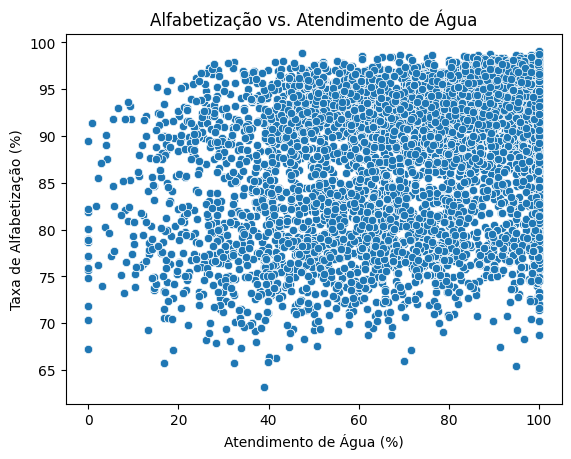

In [ ]:
# Calcular taxa de alfabetização por município
alfab = df_merged[df_merged['alfabetizacao'] == 'Alfabetizadas'].groupby('id_municipio')['populacao'].sum()
total = df_merged.groupby('id_municipio')['populacao'].sum()
taxa_alfabetizacao = (alfab / total * 100).reset_index()
taxa_alfabetizacao.columns = ['id_municipio', 'taxa_alfabetizacao']

df_merged = pd.merge(df_merged, taxa_alfabetizacao, on='id_municipio', how='left')

sns.scatterplot(
    x='indice_atendimento_total_agua',
    y='taxa_alfabetizacao',
    data=df_merged
)
plt.title("Alfabetização vs. Atendimento de Água")
plt.xlabel("Atendimento de Água (%)")
plt.ylabel("Taxa de Alfabetização (%)")
plt.show()


**Conclusões**  
* A maioria dos municípios apresenta taxas de alfabetização acima de 85%, independentemente do acesso a água potável/tratada.
* Conforme o atendimento de água aumenta, a concentração de municípios com alta alfabetização (>95%) também aumenta. O que indica que o acesso a água tratada tem uma certa influência no nível de alfabetização, mas que há outros fatoress que parece ter mais influência.  

/tmp/ipython-input-292-3114255708.py:16: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


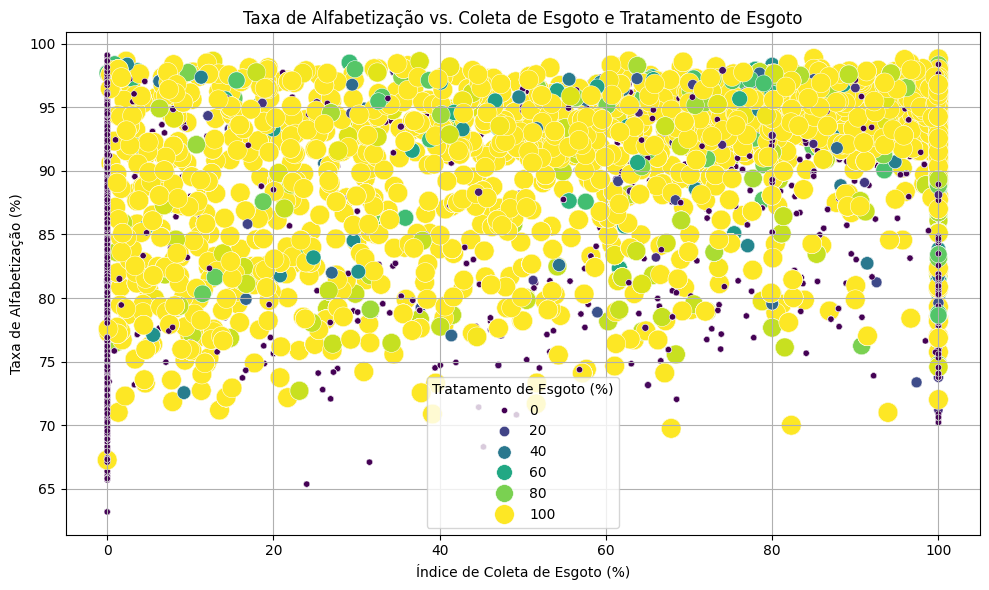

In [ ]:

plt.figure(figsize=(10, 6))
scatter = sns.scatterplot(
    x='indice_coleta_esgoto',
    y='taxa_alfabetizacao',
    hue='indice_tratamento_esgoto',
    size='indice_tratamento_esgoto',
    sizes=(20, 200),
    palette='viridis',
    data=df_merged
)
plt.title("Taxa de Alfabetização vs. Coleta de Esgoto e Tratamento de Esgoto")
plt.xlabel("Índice de Coleta de Esgoto (%)")
plt.ylabel("Taxa de Alfabetização (%)")
plt.legend(title='Tratamento de Esgoto (%)')
plt.grid(True)
plt.tight_layout()
plt.show()


**Conclusões**  
* A maioria dos municípios tem taxas de alfabetização acima de 85%, mesmo para níveis baixos de coleta de esgoto.
* O gráfico sugere que há uma associação fraca ou inexistente entre a taxa de alfabetização e a cobertura de coleta de esgoto. Visto que há cidades com baixa taxa de coleta de esgoto, mas com taxa superior a 85%. O que pode indicar que outros fatores também influenciam fortemente a alfabetização.
* Municípios com altos índices de tratamento de esgoto (circculos/pontos maiores - amarelos) também estão distribuídos em toda a faixa de alfabetização, inclusive entre cidades com taxas abaixo de 80%. Isso reforça a ideia de que tratamento de esgoto, por si só, não garante alta taxa de alfabetização.

## Heatmap de correlação:  
*O heatmap mostra as correlações de Pearson entre suas variáveis principais. Valores próximos de:*  
* +1: correlação positiva forte  
* 0: nenhuma correlação  
* -1: correlação negativa forte  

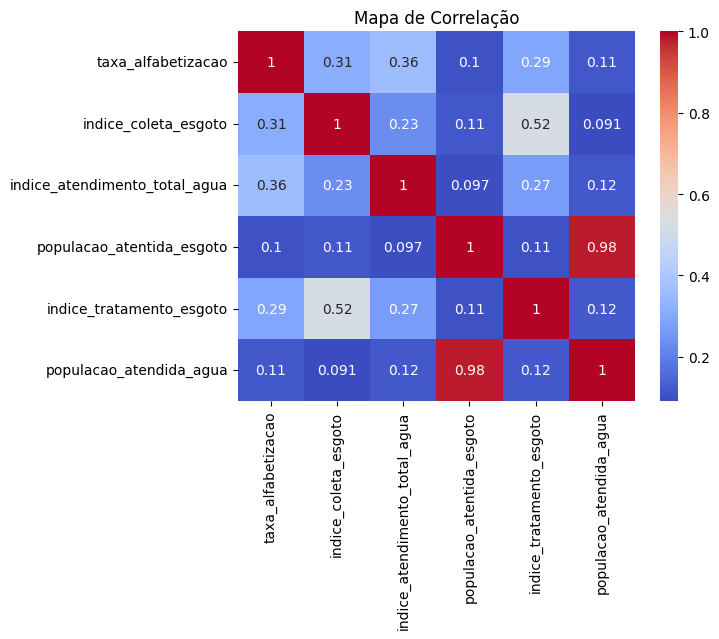

In [ ]:
colunas = ['taxa_alfabetizacao', 'indice_coleta_esgoto', 'indice_atendimento_total_agua', 'populacao_atentida_esgoto', 'indice_tratamento_esgoto',
		   'populacao_atendida_agua']
# Calcula a matriz de correlação apenas com as colunas numéricas de interesse
corr_matrix = df_merged[colunas].corr()

sns.heatmap(
	corr_matrix,
	annot=True,
	cmap='coolwarm'
)
plt.title('Mapa de Correlação')
plt.show()

**Conclusões**  
* Os indíces de população de água e esgoto são fortemente correlacionados (0.98).
* Moderada dependência entre coleta e tratamento de esgoto (0.52).
* A correlação de Pearson indica uma relação positiva (porém fraca) entre os índices de atendimento de água/esgoto e a taxa de alfabetização nos municípios. Esses resultados sugerem que melhorias no saneamento podem estar associadas a maiores taxas de alfabetização, mas não são necessariamente a causa principal.
* São necessários mais dados para poder afirmar categoricamente uma relação entre analfabetismo e acesso ao saneamento, como por exempo, a renda familiar etc.

### Boxplot

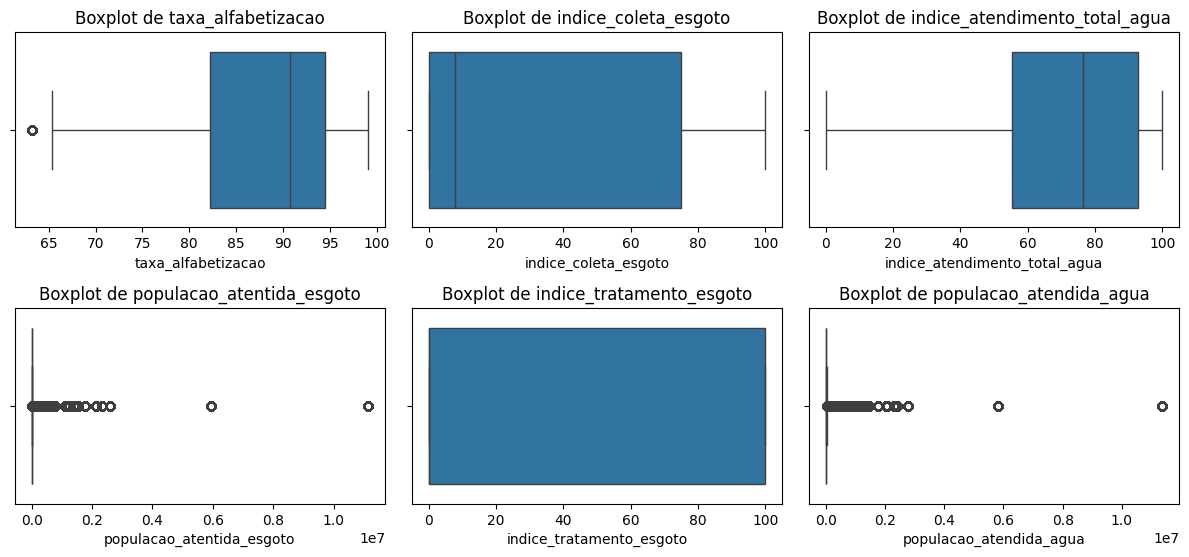

In [ ]:
plt.figure(figsize=(12, 8))
for i, col in enumerate(colunas, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(x=df_merged[col])
    plt.title(f"Boxplot de {col}")
plt.tight_layout()
plt.show()

**Conclusões**
* A alfabetização brasileira é mais homogênea, mas sofre influência de fatores regionais.
* O saneamento básico (água e esgoto) ainda é muito desigual, com ampla variação entre municípios.
* Coleta e tratamento de esgoto são especialmente baixos na maioria dos municípios.

### Histograma

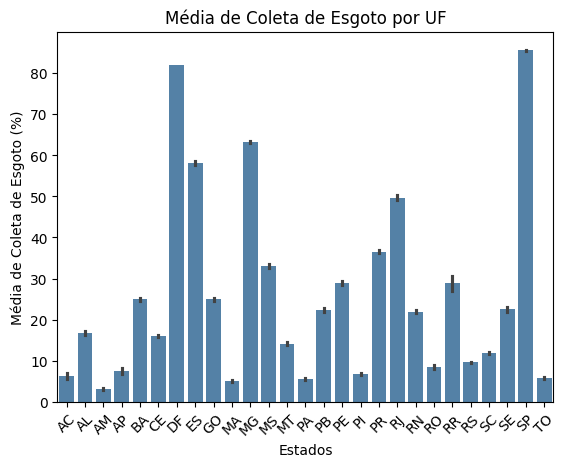

In [ ]:
sns.barplot(
    x='sigla_uf',
    y='indice_coleta_esgoto',
    data=df_merged,
    estimator=np.mean,
    color='#4682B4'
)
plt.title("Média de Coleta de Esgoto por UF")
plt.xlabel("Estados")
plt.ylabel("Média de Coleta de Esgoto (%)")
plt.xticks(rotation=45)
plt.show()

**Conclusões**
* Os estados do Sudeste (São Paulo, Rio de Janeiro, Espírito Santos e Minas Gerais) apresentaram os melhores índices de coletas de esgoto no geral.
* No geral, Norte e Nordeste possuem os piores índices.
* Estados mais ricos e populosos tendem a ter maior coleta de esgoto.
* A maiorias das unidades federativas possuem uma baixa coleta de esgoto.